# **Modelo XGBoost Clasificación + *Feature Engineering***

En este notebook se entrena una nueva versión del modelo de clasificación para la predicción del tiempo total de entrega utilizando técnicas de feature engineering y nuevas fuentes de información externas.

El objetivo es predicir la `target_class`, definido en base al tiempo (en minutos) transcurrido entre:
- `courier_started_order_local`
- `delivery_time_local`

Este notebook corresponde al enfoque de clasificación directa, donde el modelo predice directamente el rango temporal de entrega. En paralelo, también se desarrolló un enfoque de regresión equivalente para poder comparar ambos paradigmas bajo las mismas técnicas de enriquecimiento de variables.

Tras entrenar los modelos baseline utilizando únicamente las variables originales del dataset, se observó que el rendimiento estaba probablemente más limitado por la información disponible en las features que por la complejidad del algoritmo utilizado.

Por ello, en esta segunda iteración se incorporan nuevas variables relacionadas con:

- tipo de establecimiento,
- condiciones meteorológicas,
- localización geográfica,
- tráfico y flujo urbano,
- complejidad del pedido,
- comportamiento temporal de la demanda.

El modelo utilizado será XGBoost, ya que fue el modelo con mejor rendimiento en el notebook `Modelo_Baseline_Clasif`.

In [1]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from category_encoders import TargetEncoder
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1. Descripción general del dataset**

In [5]:
# Carga de datos
df = pd.read_csv("/content/drive/MyDrive/Reto_IA/dataset_nuevas_features.csv")

El dataset contiene variables operacionales, temporales, meteorológicas y geográficas relacionadas con el proceso de entrega.

In [ ]:
df.columns

Index(['store_name', 'vertical', 'gtv', 'delivery_fee',
       'activation_time_local', 'courier_started_order_local',
       'pickup_time_local', 'delivery_time_local', 'tranport_type',
       'saturation', 'distance_km', 'hour', 'day_of_week', 'is_weekend',
       'day_name', 'target', 'target_min', 'target_class', 'store_type',
       'Total_Unidades', 'Articulos_Distintos', 'weather_code', 'precip_mm',
       'weather_desc', 'distrito_pickup', 'distrito_delivery', 'dist_p_centro',
       'dist_d_centro', 'cruza_periferico', 'flujo', 'is_test'],
      dtype='object')

In [ ]:
df.head()

,store_name,vertical,gtv,delivery_fee,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,saturation,...,weather_code,precip_mm,weather_desc,distrito_pickup,distrito_delivery,dist_p_centro,dist_d_centro,cruza_periferico,flujo,is_test
0,PHARMACIE,WALL - Partner,19.97,4.9,2019-10-01 09:21:00,2019-10-01 09:19:06.342,2019-10-01 09:34:55.904,2019-10-01 09:50:02,MOTORBIKE,66,...,51.0,0.1,Llovizna ligera,16.0,16.0,5.637138,5.038016,0,Centrípeto,False
1,STARBUCKS,WALL - NonPartner,10.50,4.9,2019-10-01 09:18:00,2019-10-01 09:28:04.560,2019-10-01 09:36:02.133,2019-10-01 09:47:39,BICYCLE,40,...,51.0,0.1,Llovizna ligera,8.0,16.0,3.866667,4.497923,0,Centrífugo,False
2,STARBUCKS,WALL - NonPartner,10.35,4.9,2019-10-01 15:04:00,2019-10-01 15:04:28.032,2019-10-01 15:25:37.131,2019-10-01 15:34:52,MOTORBIKE,29,...,53.0,0.5,Llovizna moderada,4.0,11.0,0.640054,1.452745,0,Centrífugo,False
3,NO_STORE,COURIER,6.60,6.6,2019-10-02 10:08:00,2019-10-02 10:11:26.078,2019-10-02 10:30:24.559,2019-10-02 10:50:13,MOTORBIKE,54,...,0.0,0.0,Despejado,16.0,0.0,4.877379,7.415955,1,Centrífugo,False
4,FRANPRIX,WALL - Partner,13.10,3.9,2019-10-02 12:12:00,2019-10-02 12:10:54.226,2019-10-02 12:31:21.010,2019-10-02 12:38:04,MOTORBIKE,77,...,51.0,0.1,Llovizna ligera,3.0,11.0,1.005934,1.879541,0,Centrífugo,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63589 entries, 0 to 63588
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   store_name                   63589 non-null  object 
 1   vertical                     63589 non-null  object 
 2   gtv                          63589 non-null  float64
 3   delivery_fee                 63589 non-null  float64
 4   activation_time_local        63589 non-null  object 
 5   courier_started_order_local  63589 non-null  object 
 6   pickup_time_local            63589 non-null  object 
 7   delivery_time_local          63589 non-null  object 
 8   tranport_type                63589 non-null  object 
 9   saturation                   63589 non-null  int64  
 10  distance_km                  63589 non-null  float64
 11  hour                         63589 non-null  int64  
 12  day_of_week                  63589 non-null  int64  
 13  is_weekend      

## **2. Preprocesamiento y *Feature Engineering***

En esta sección se realizan transformaciones orientadas a:
- mejorar la calidad de los datos,
- reducir ruido,
- generar variables más representativas del problema,
- incorporar conocimiento de negocio al modelo.

In [6]:
# Para trabajar de forma segura sobre una copia del dataset original
df_mod = df.copy()

### **2.0 Unión con el DataFrame original**

In [7]:
df_original = pd.read_csv("/content/drive/MyDrive/Reto_IA/glovo_ops_data_final.csv")

for col in ['pickup_time_local', 'delivery_time_local']:
    df_mod[col] = pd.to_datetime(df_mod[col]).dt.floor('s')
    df_original[col] = pd.to_datetime(df_original[col]).dt.floor('s')

df_mod['gtv'] = df_mod['gtv'].round(2)
df_original['gtv'] = df_original['gtv'].round(2)

llave = ['pickup_time_local', 'delivery_time_local', 'gtv']

df_mod = df_mod.merge(
    df_original[llave + ['courier_id', 'store_address_id', 'order_id']].drop_duplicates(subset=llave),
    on=llave,
    how='left'
)

### **2.1 Tratamiento de valores nulos en variables climáticas**

Las variables climáticas fueron obtenidas mediante una API externa, por lo que algunos registros no pudieron ser recuperados correctamente y presentan valores nulos.

Dado que las condiciones meteorológicas suelen mantenerse relativamente estables en ventanas cortas de tiempo, se decide imputar estos valores utilizando el clima registrado más cercano temporalmente, con un margen máximo de 60 minutos.

En aquellos casos donde esto no sea posible, se utilizará:
- la moda para variables categóricas,
- el valor 0 para precipitación (`precip_mm`).

In [8]:
df_mod['activation_time_local'] = pd.to_datetime(df_mod['activation_time_local'])
df_mod = df_mod.sort_values('activation_time_local')

UMBRAL_MINUTOS = 60

# Variables afectadas
col_clima = ['weather_desc', 'weather_code', 'precip_mm']

Se crea una estructura auxiliar para registrar:
- nulos originales,
- valores recuperados mediante proximidad temporal,
- valores imputados mediante moda o cero.

In [9]:
audit = {
    'inicial': df_mod[col_clima].isna().sum(),
    'rescatados_temporal': {c: 0 for c in col_clima},
    'asignados_moda': {c: 0 for c in col_clima}
}

Imputación temporal:

In [10]:
nulos_originales = df_mod[col_clima].isna()

df_mod['delta_next'] = df_mod['activation_time_local'].diff().dt.total_seconds() / 60

df_mod[col_clima] = df_mod[col_clima].ffill()

Para evitar imputaciones incorrectas entre pedidos muy separados temporalmente, se invalidan aquellos casos donde la distancia temporal supera los 60 minutos.

In [11]:
for col in col_clima:
    mask_invalidar = (df_mod['delta_next'] > UMBRAL_MINUTOS) & nulos_originales[col]
    df_mod.loc[mask_invalidar, col] = np.nan

    audit['rescatados_temporal'][col] = nulos_originales[col].sum() - df_mod[col].isna().sum()

Imputación final:

In [12]:
nulos_precip_restantes = df_mod['precip_mm'].isna().sum()
df_mod['precip_mm'] = df_mod['precip_mm'].fillna(0)
audit['asignados_moda']['precip_mm'] = nulos_precip_restantes

for col in ['weather_desc', 'weather_code']:
    nulos_restantes = df_mod[col].isna().sum()
    moda_val = df_mod[col].mode()[0]
    df_mod[col] = df_mod[col].fillna(moda_val)
    audit['asignados_moda'][col] = nulos_restantes

df_mod = df_mod.drop(columns=['delta_next'])

**Resultado del proceso:**

In [13]:
print("Asignación")
print("-" * 55)
for col in col_clima:
    print(f"Variable: {col}")
    print(f"  - Nulos iniciales:     {audit['inicial'][col]}")
    print(f"  - Rescatados (ffill):  {audit['rescatados_temporal'][col]}")
    print(f"  - Asignados (Moda/0):  {audit['asignados_moda'][col]}")
    print(f"  - Estado final:        {df_mod[col].isna().sum()} nulos")
    print("-" * 30)

Asignación
-------------------------------------------------------
Variable: weather_desc
  - Nulos iniciales:     6765
  - Rescatados (ffill):  6755
  - Asignados (Moda/0):  10
  - Estado final:        0 nulos
------------------------------
Variable: weather_code
  - Nulos iniciales:     6765
  - Rescatados (ffill):  6755
  - Asignados (Moda/0):  10
  - Estado final:        0 nulos
------------------------------
Variable: precip_mm
  - Nulos iniciales:     6765
  - Rescatados (ffill):  6755
  - Asignados (Moda/0):  10
  - Estado final:        0 nulos
------------------------------


- Más del 99% de los nulos climáticos pudieron recuperarse mediante proximidad temporal.
- Solo 10 registros requirieron imputación mediante moda o valor cero.
- Finalmente, ninguna variable climática presenta valores faltantes.

### **2.2 Creación de la variable `tiempo_asignación`**

Se crea una nueva variable que representa el tiempo transcurrido entre:
- la activación del pedido (`activation_time_local`)
- el momento en que el repartidor inicia el pedido (`courier_started_order_local`)

In [14]:
df_mod['courier_started_order_local'] = pd.to_datetime(df_mod['courier_started_order_local'], errors='coerce')
df_mod['activation_time_local'] = pd.to_datetime(df_mod['activation_time_local'], errors='coerce')
df_mod['tiempo_asignacion'] = (df_mod['courier_started_order_local'] - df_mod['activation_time_local']).dt.total_seconds() / 60

### **2.3 Creación de la variable `pre_asignacion`**

Existen casos donde el repartidor ya estaba preasignado antes de que el pedido fuese oficialmente activado, lo que genera tiempos negativos en `tiempo_asignacion`.

Para representar este comportamiento se crea una variable binaria `pre_asignacion` y posteriormente los tiempos negativos se ajustan a cero.

In [15]:
df_mod['pre_asignacion'] = (df_mod['tiempo_asignacion'] < 0).astype(int)
df_mod.loc[df_mod['tiempo_asignacion'] < 0, 'tiempo_asignacion'] = 0

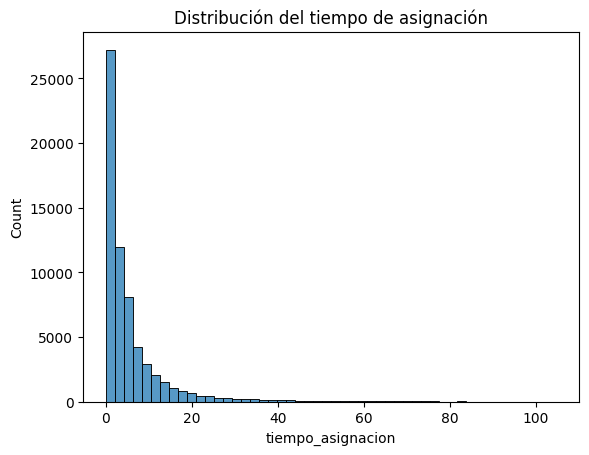

In [16]:
sns.histplot(df_mod['tiempo_asignacion'], bins=50)
plt.title("Distribución del tiempo de asignación")
plt.show()

### **2.4 Variables temporales derivadas**


Se utilizan las fechas de inicio real del pedido (`courier_started_order_local`) para generar variables temporales más interpretables para el modelo.

In [17]:
df_mod['courier_started_order_local'] = pd.to_datetime(df_mod['courier_started_order_local'], errors='coerce')

df_mod['mes'] = df_mod['courier_started_order_local'].dt.month.astype(str)
df_mod['hora']  = df_mod['courier_started_order_local'].dt.hour

La variable `mes` se convierte a *string* para tratarla como una categoría nominal y no como una variable ordinal.

**Creación de franjas horarias**

El comportamiento de los usuarios en plataformas de *delivery* presenta patrones horarios muy marcados, especialmente durante el almuerzo y la cena. Para capturar este comportamiento se crea la variable `franja_horaria`.

In [18]:
df_mod['franja_horaria'] = pd.cut(
    df_mod['hora'],
    bins=[-1, 6, 11, 14, 18, 22, 24],
    labels=[
        'madrugada',
        'mañana',
        'almuerzo',
        'tarde',
        'cena',
        'noche'
    ]
)

### **2.6 Eliminación de variables**

Se eliminan variables:
- redundantes,
- derivadas del target,
- con posible fuga de información,
- o sustituidas por nuevas variables más interpretables.

In [19]:
df_mod = df_mod.drop(columns=['activation_time_local', 'pickup_time_local',	'delivery_time_local', 'target', 'day_name','hour','is_weekend', 'courier_started_order_local', 'weather_code', 'order_id'])

**Variables temporales originales**
- `delivery_time_local` contiene información directa del objetivo.
- `activation_time_local`, `pickup_time_local` y `courier_started_order_local` fueron reemplazadas por variables derivadas más interpretables.

**Variables derivadas o redundantes**
- `target` y `target_class` derivan del objetivo.
- `day_name`, `hour` e `is_weekend` fueron reemplazadas por nuevas representaciones temporales.

**Variables de alta cardinalidad**
- `store_name` se elimina para evitar sobreajuste y *sparsity* excesiva.

**Variables redundantes del clima**
- `weather_code` se elimina porque `weather_desc` resulta más interpretable.

**Eliminación de valores faltantes restantes**

Antes de continuar, se verifica el número de registros con valores nulos restantes. Estos representan una muy baja cantidad del total y dado que el XGBoost permite procesar NaNs no son eliminados.

In [20]:
df_mod.isna().sum()

,0
store_name,0
vertical,0
gtv,0
delivery_fee,0
tranport_type,0
saturation,0
distance_km,0
day_of_week,0
target_min,0
target_class,0


### **2.7 Agrupación de categorías poco representadas**

La categoría `pharmacy` dentro de `store_type` presenta baja frecuencia y comportamiento similar a la categoría `retail`, por lo que se agrupa dentro de ella.

In [21]:
df_mod.loc[df_mod['store_type'] == 'pharmacy', 'store_type'] = 'retail'

### **2.8 Conversión de variables categóricas no ordinales**

Algunas variables numéricas representan categorías sin orden inherente, por lo que se convierten a string para asegurar un tratamiento categórico adecuado.

In [22]:
df_mod['distrito_pickup_str'] = df_mod['distrito_pickup'].astype(str)
df_mod['distrito_delivery_str'] = df_mod['distrito_delivery'].astype(str)
df_mod['day_of_week_str'] = df_mod['day_of_week'].astype(str)

df_mod = df_mod.drop(columns=['distrito_pickup', 'distrito_delivery', 'day_of_week'])

### **2.9 Agrupación de condiciones climáticas**

Para reducir cardinalidad y simplificar patrones climáticos, se agrupan las descripciones meteorológicas en categorías más generales.

In [23]:
# Definimos el diccionario de agrupación
clima_mapping = {
    'Despejado': 'buen_tiempo',
    'Principalmente despejado': 'buen_tiempo',
    'Parcialmente nublado': 'buen_tiempo',
    'Nublado': 'nublado',
    'Llovizna ligera': 'lluvia_ligera',
    'Llovizna moderada': 'lluvia_ligera',
    'Lluvia ligera': 'clima_adverso',
    'Llovizna densa': 'clima_adverso',
    'Nieve moderada': 'clima_adverso',
    'Nieve ligera': 'clima_adverso',
    'Lluvia moderada': 'clima_adverso'
}

# Aplicamos la agrupación
df_mod['clima_agrupado'] = df_mod['weather_desc'].map(clima_mapping)

# Verificamos la nueva distribución
print(df_mod['clima_agrupado'].value_counts())

clima_agrupado
nublado          28578
buen_tiempo      18950
lluvia_ligera    13919
clima_adverso     2142
Name: count, dtype: int64


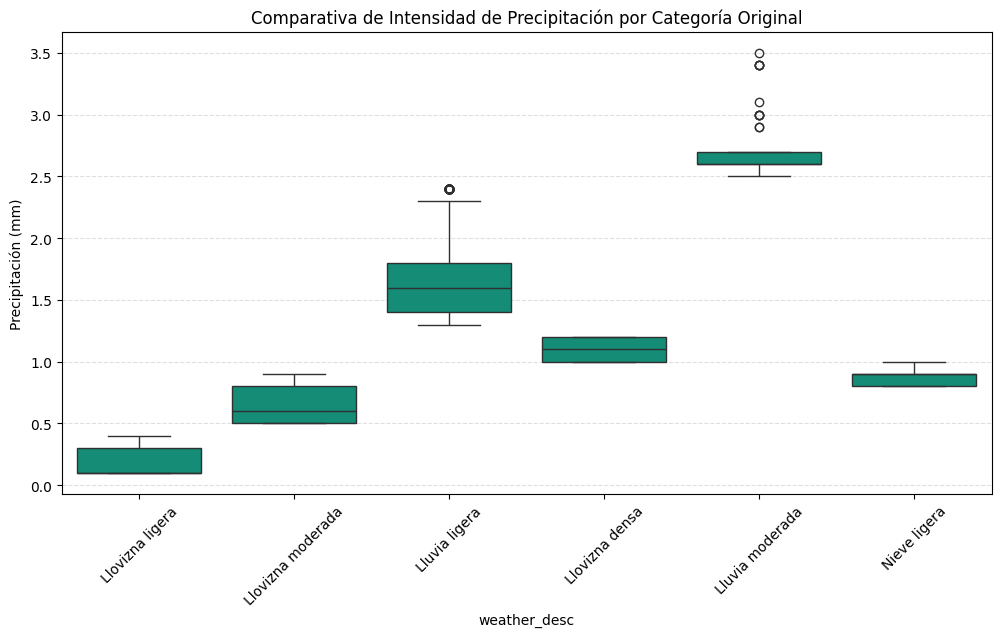

In [24]:
weather_to_analyze = [
    'Llovizna ligera', 'Llovizna moderada',
    'Llovizna densa', 'Lluvia ligera', 'Lluvia moderada', 'Nieve ligera'
]

df_weather = df_mod[df_mod['weather_desc'].isin(weather_to_analyze)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_weather, x='weather_desc', y='precip_mm', color='#00a082')


plt.title('Comparativa de Intensidad de Precipitación por Categoría Original')
plt.xticks(rotation=45)
plt.ylabel('Precipitación (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('analisis_clima_tfm.png')

In [25]:
df_mod = df_mod.drop(columns=['weather_desc'])

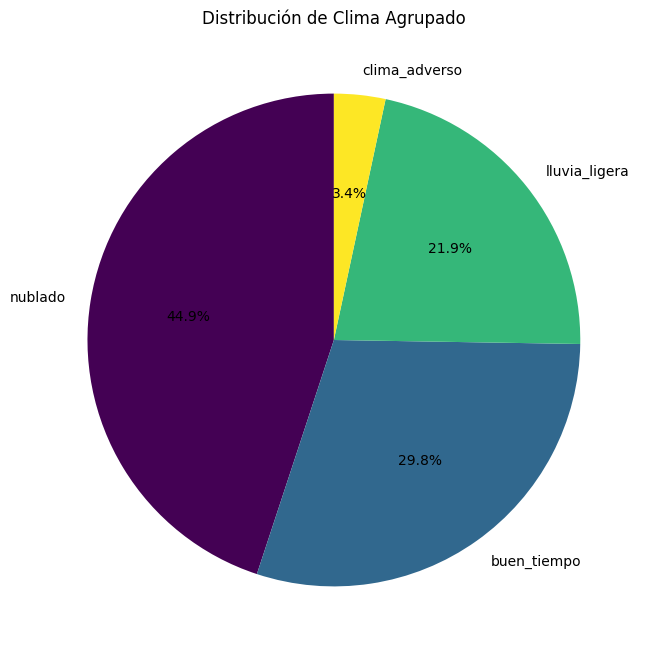

In [26]:
plt.figure(figsize=(8, 8))
df_mod['clima_agrupado'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribución de Clima Agrupado')
plt.ylabel('')
plt.show()

Podemos identificar que la mayor cantidad de valores corresponde a nublado seguido por buen tiempo. Mientras que el valor de lluvia_ligera es prácticamente un quinto de lo valores (21.9%) mientras que el clima_adverso es solo 3.4%.

### **2.10 Transformación de precipitación**

La variable `precip_mm` presenta una distribución altamente asimétrica con fuerte concentración en cero. Para suavizar valores extremos se aplica una transformación logarítmica.

In [27]:
df_mod['precip_mm'] = np.log1p(df_mod['precip_mm'])

### **2.11 Modificación de Total Unidades**

Leyendo la descripción de los valores mas altos de la variable Total_Unidades, identificamos que los valores 81 y 73 son incorrectamente imputados. Por lo tanto, estos corresponden a valores de 1 y por ende se realiza el reemplazo.

In [28]:
df_mod['Total_Unidades'] = df_mod['Total_Unidades'].replace([81, 73], 1)

In [29]:
print(df_mod[['Total_Unidades']].describe().round(2))

       Total_Unidades
count        63589.00
mean             3.37
std              3.33
min              1.00
25%              1.00
50%              2.00
75%              4.00
max             61.00


### **2.12 Articulos Distintos**

Aplicamos un describe para visualizar los valores de los cuartiles y montos mínimos y máximos.

In [30]:
print(df_mod[['Articulos_Distintos']].describe().round(2))

       Articulos_Distintos
count             63589.00
mean                  2.70
std                   2.39
min                   1.00
25%                   1.00
50%                   2.00
75%                   3.00
max                  33.00


### **2.13 Relación con la variables precipitación**

Con el objetivo de mejorar la capacidad predictiva del modelo, se generaron interacciones entre variables. Específicamente, se evaluó el producto de la precipitación por la distancia y la saturación, con el fin de capturar posibles relaciones no lineales con los factores ambientales.

In [31]:
df_mod['lluvia_x_saturacion'] = df_mod['precip_mm'] * df_mod['saturation']

In [32]:
df_mod['precip_x_distancia'] = df_mod['precip_mm'] * df_mod['distance_km']

### **2.14 Relación entre la saturación y distancia**

Probamos de ver si la interacción entre la variable `saturation` y `distance_km` funcionaban. No obstante, la dejamos de ejecutar dado que empeoraba la capacidad predictiva del modelo.

In [33]:
#df_mod['saturation_x_distancia'] = df_mod['saturation'] * df_mod['distance_km']

### **2.15 Entrega y envío en mismos distritos**

Como parte de la fase iterativa probamos crear una variable *booleana* donde el recojo y la entrega del pedido fueran en el mismo distrito. El objetivo es reflejar el comportamiento de movilidad similar que existe en un mismo distrito, mas allá de simplemente tener la distancia recorrida.

In [34]:
df_mod['mismo_distrito'] = (df_mod['distrito_pickup_str'] == df_mod['distrito_delivery_str']).astype(int)

### **2.16 Eliminación de outliers**

Desde el EDA habíamos identificado que existen valores bastante elevados relacionados a la variable objetivo.

In [35]:
tiempos_mayores_90 = df_mod[df_mod['target_min'] > 90]
count_mayores_90 = len(tiempos_mayores_90)
percentage_mayores_90 = (count_mayores_90 / len(df_mod)) * 100

print(f"Número de tiempos de entrega mayores a 90 minutos: {count_mayores_90}")
print(f"Porcentaje de tiempos de entrega mayores a 90 minutos: {percentage_mayores_90:.2f}%")

Número de tiempos de entrega mayores a 90 minutos: 216
Porcentaje de tiempos de entrega mayores a 90 minutos: 0.34%


Analizamos la distribución de las los `store_types` en base a los tiempos mayores a 90 minutos.

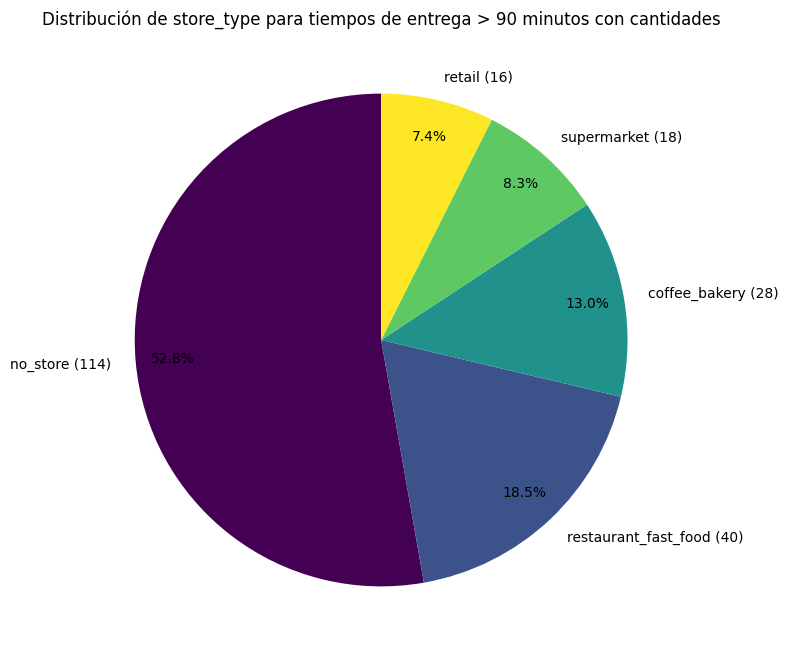

In [36]:
store_type_counts = tiempos_mayores_90['store_type'].value_counts()

labels = [f'{idx} ({val})' for idx, val in store_type_counts.items()]

plt.figure(figsize=(8, 8))
store_type_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis', labels=labels, pctdistance=0.85)
plt.title('Distribución de store_type para tiempos de entrega > 90 minutos con cantidades')
plt.ylabel('')
plt.show()

Identificamos que el `no_store` es el tipo de servicio que tiene mayor cantidad seguramente debido a que son pedidos de courier donde no existe tienda. Es decir, el servicio es punto a punto (envíos personales) y pueden presentarse ciertas dificultades en los pedidos por no ser tan estandarizados como los pedidos a restaurantes, cafeterías, etc.

No obstante, dejamos de ejecutar esta eliminación debido a que la capacidad predictiva del modelo empeora al eliminar estas variables.

In [37]:
# No lo ejecutamos porque el modelo empeora
#df_mod = df_mod.drop('tiempo_asignacion',axis=1)
#df_mod = df_mod[((df_mod['target_min'] <= 90) & (df_mod['is_test'] == False)) |(df_mod['is_test'] == True)]

## **3. Métricas de evaluación**

Dado que el problema consiste en la predicción de tiempos de entrega, se utilizan distintas métricas complementarias para evaluar tanto la precisión general del modelo como su impacto desde una perspectiva de negocio.

In [38]:
def asymmetric_error(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)


    penalty_matrix = np.array([

  # pred: 0    1    2    3    4

        [0.0, 1.0, 1.5, 2.0, 3.0],  # real = 0
        [1.0, 0.0, 1.0, 1.5, 2.5],  # real = 1
        [1.5, 1.0, 0.0, 1.0, 2.0],  # real = 2
        [2.0, 1.5, 1.0, 0.0, 1.0],  # real = 3
        [3.0, 2.5, 2.0, 1.0, 0.0]   # real = 4
    ])

    penalties = penalty_matrix[y_true, y_pred]

    return np.mean(penalties)


custom_scorer = make_scorer(
    asymmetric_error,
    greater_is_better=False # porque menores penalizaciones representan mejor desempeño
)

# Conjunto de métricas utilizadas
scoring = {
    'custom': custom_scorer,
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro'
}

## **4. Train, validation, test split**

El dataset ya contiene una columna `is_test`, utilizada para separar explícitamente el conjunto de prueba final.

In [39]:
train_val_df = df_mod[df_mod['is_test'] == False]
test_df = df_mod[df_mod['is_test'] == True]

Separación de variables predictoras y variable objetivo:

In [40]:
X_train_val = train_val_df.drop(columns=['target_min', 'is_test', 'target_class'])
y_train_val = train_val_df['target_class']

In [41]:
X_test = test_df.drop(columns=['target_min', 'is_test', 'target_class'])
y_test = test_df['target_class']

## **5. Modelo XGBoost**

Las variables definidas como `te_feat` presentan una alta cardinalidad. Aplicar One-Hot Encoding sobre ellas generaría una matriz extremadamente dispersa y un
mayor riesgo de sobreajuste. Por ello se utiliza Target Encoding, que reemplaza cada categoría por una estimación suavizada del target promedio asociado

In [42]:
# Definición de variables
cat_feat = ['vertical', 'tranport_type', 'store_type', 'flujo', 'mes', 'franja_horaria', 'clima_agrupado', 'distrito_pickup_str', 'distrito_delivery_str', 'day_of_week_str']
num_feat = ['gtv', 'delivery_fee', 'saturation', 'distance_km','hora', 'Total_Unidades', 'Articulos_Distintos', 'precip_mm', 'dist_p_centro', 'dist_d_centro', 'cruza_periferico','tiempo_asignacion', 'pre_asignacion','mismo_distrito', 'lluvia_x_saturacion', 'precip_x_distancia']
te_feat = ['store_name', 'courier_id', 'store_address_id']

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feat),
        ('cat_te', TargetEncoder(cols=['store_name', 'courier_id', 'store_address_id'], smoothing=10), te_feat)], # El parámetro smoothing=10 ayuda a reducir sobreajuste en categorías poco frecuentes
        remainder='passthrough')

pipe_xgb = Pipeline([
    ('prep', preprocessor_xgb),
    ('model', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

Se realiza una búsqueda mediante `GridSearchCV` para encontrar la mejor combinación de hiperparámetros.

In [43]:
# Búsqueda de hiperparámetros
param_grid_xgb = {
    'model__n_estimators': [200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

# Validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Entrenamiento del Grid Search
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring=scoring,
    refit='custom',
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train_val, y_train_val)

print(grid_xgb.best_params_)
print("Best custom score:", grid_xgb.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best custom score: -0.4508570403239167


In [44]:
results_xgb = pd.DataFrame(grid_xgb.cv_results_)

results_xgb[[
    'params',
    'mean_test_custom',
    'mean_test_accuracy',
    'mean_test_f1_macro',
    'mean_test_recall_macro'
]].sort_values('mean_test_custom', ascending=False)

,params,mean_test_custom,mean_test_accuracy,mean_test_f1_macro,mean_test_recall_macro
2,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.450857,0.566481,0.510512,0.473117
3,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.452577,0.565380,0.509060,0.471359
6,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.452901,0.563964,0.508262,0.471778
8,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.452911,0.564711,0.517142,0.481142
9,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.452921,0.565026,0.516115,0.479288
4,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.453550,0.564063,0.515755,0.479000
7,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.453914,0.563355,0.506508,0.470219
5,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.456391,0.561763,0.512294,0.475980
10,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.457884,0.560583,0.515000,0.480804
0,"{'model__learning_rate': 0.05, 'model__max_dep...",-0.459388,0.558559,0.490995,0.457639


Los resultados muestran diferencias relativamente pequeñas entre configuraciones, lo que sugiere que el modelo es estable,
las nuevas variables aportan información consistente,
y el rendimiento está más condicionado por la calidad de las *features* que por pequeños cambios en hiperparámetros.

## **6. Evaluación sobre el conjunto de test**

### **6.1 Reentrenamiento del modelo final**

Una vez encontrados los mejores hiperparámetros, se reentrena el modelo utilizando todo el conjunto *train* + *validation*.

In [45]:
best_xgb = grid_xgb.best_estimator_

best_xgb.fit(X_train_val, y_train_val)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['vertical', 'tranport_type',
                                                   'store_type', 'flujo', 'mes',
                                                   'franja_horaria',
                                                   'clima_agrupado',
                                                   'distrito_pickup_str',
                                                   'distrito_delivery_str',
                                                   'day_of_week_str']),
                                                 ('cat_te',
                                                  TargetEncoder(cols=['store_name',
                                                                      'courier_id',
                                                                      'store_addres...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### **6.2 Evaluación en conjunto de test**

El modelo genera predicciones sobre el target transformado logarítmicamente.

In [46]:
# Predicciones en test
y_pred = best_xgb.predict(X_test)

In [47]:
# Evaluar métricas
acc_test    = accuracy_score(y_test, y_pred)
f1_test     = f1_score(y_test, y_pred, average='macro')
custom_test = asymmetric_error(y_test, y_pred)


print("TEST Accuracy:", round(acc_test, 3))
print("TEST F1 Macro:", round(f1_test, 3))
print("TEST CUSTOM:",   round(custom_test, 3))

TEST Accuracy: 0.571
TEST F1 Macro: 0.515
TEST CUSTOM: 0.445


Comparando con el modelo base:

In [3]:
summary_results = pd.DataFrame({
    'Modelo': [
        'Accuracy',
        'F1 Macro',
        'Custom'
    ],

    'XGBoost Base Clasif': [
        0.521,
        0.418,
        0.51
    ],

    'XGBoost Clasif + Feature Engineering': [
        0.571,
        0.515,
        0.445
    ]
})

summary_results

,Modelo,XGBoost Base Clasif,XGBoost Clasif + Feature Engineering
0,Accuracy,0.521,0.571
1,F1 Macro,0.418,0.515
2,Custom,0.510,0.445


La incorporación de nuevas variables mediante *feature engineering* produce una mejora en todas las métricas evaluadas.

El aumento en Accuracy indica una mejora global en la capacidad de clasificación del modelo, mientras que el incremento de casi 10 puntos en F1 Macro muestra que la mejora no se limita únicamente a las clases mayoritarias, sino que también existe un mejor equilibrio entre categorías.

Además, la reducción de la métrica Custom confirma que el modelo comete errores menos severos, reduciendo especialmente las confusiones entre clases temporalmente alejadas.

### **6.3 Feature importance**

Para interpretar el modelo se analizan las variables más relevantes según XGBoost.

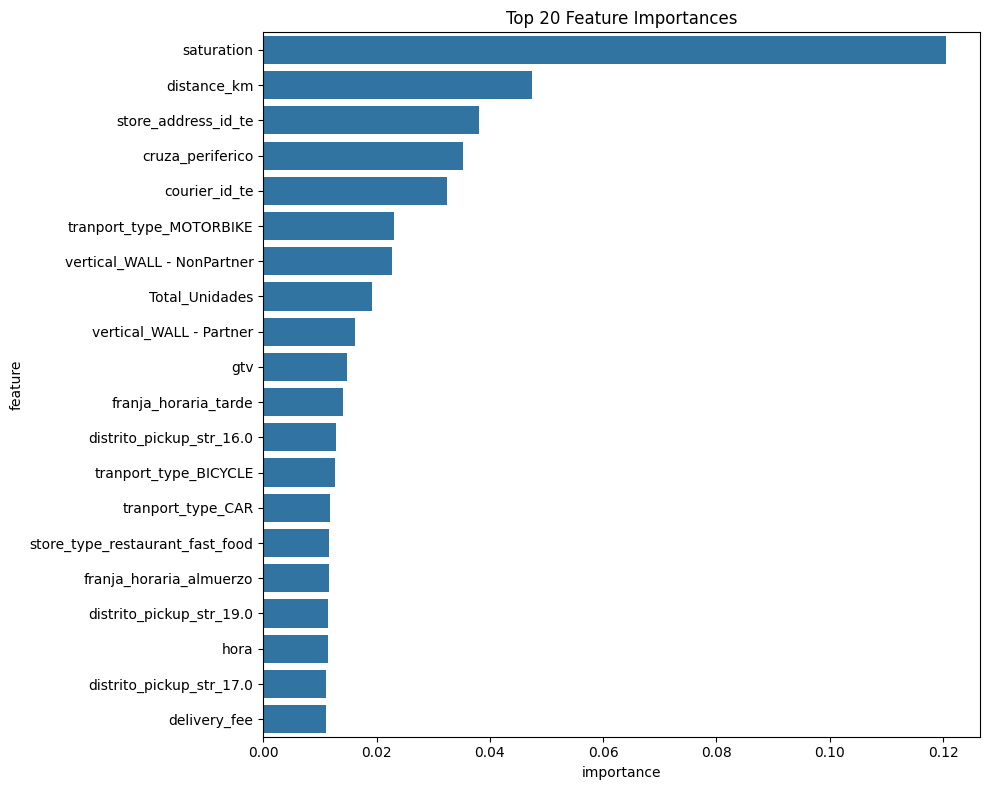

In [48]:
importances = best_xgb.named_steps['model'].feature_importances_

# Reconstrucción de nombres de variables
onehot_features = best_xgb.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_feat)
te_feature_names = ['store_name_te', 'courier_id_te', 'store_address_id_te']
all_feature_names = list(onehot_features) + te_feature_names + num_feat

feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

In [49]:
top10_feat_imp = (
    feature_importance_df[['feature', 'importance']]
    .sort_values(by='importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_feat_imp['importance'] = top10_feat_imp['importance'].round(4)

print(top10_feat_imp)

                      feature  importance
0                  saturation      0.1205
1                 distance_km      0.0474
2         store_address_id_te      0.0380
3            cruza_periferico      0.0353
4               courier_id_te      0.0324
5     tranport_type_MOTORBIKE      0.0231
6  vertical_WALL - NonPartner      0.0228
7              Total_Unidades      0.0192
8     vertical_WALL - Partner      0.0162
9                         gtv      0.0148


La variable más importante del modelo es saturation, lo que refuerza la hipótesis de que la congestión operativa tiene un impacto crítico sobre los tiempos de entrega.

En segundo lugar aparece distance_km, confirmando que la distancia recorrida continúa siendo uno de los principales drivers del ETA.

A diferencia del modelo baseline, tras el feature engineering adquieren relevancia nuevas variables geográficas como:
- distrito,
- cruce de periférico,
- distancia al centro,

las cuales aportan contexto espacial adicional y permiten capturar diferencias estructurales entre distintas zonas de operación.

Asimismo, las variables generadas mediante Target Encoding sobre courier_id y store_address_id aportan información relevante sobre patrones históricos asociados tanto a repartidores como a puntos de recogida. Esto sugiere que existen diferencias sistemáticas de rendimiento que el modelo logra aprovechar para mejorar la predicción.

En conjunto, el análisis de importancia de variables muestra que el feature engineering permitió enriquecer significativamente la representación del problema, incorporando señales operativas y geográficas que no estaban presentes en el modelo base.

### **6.4 Classification report**

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.25      0.35      1463
           1       0.53      0.65      0.59      4268
           2       0.59      0.68      0.64      4972
           3       0.56      0.33      0.41      1477
           4       0.82      0.46      0.59       537

    accuracy                           0.57     12717
   macro avg       0.62      0.47      0.52     12717
weighted avg       0.58      0.57      0.56     12717



La principal mejora se observa en la capacidad de detectar correctamente las clases extremas, especialmente la clase 0 (entregas rápidas):
- Recall clase 0 baseline: 0.09
- Recall clase 0 feature engineering: 0.25

Esto indica que el nuevo conjunto de variables permite identificar con mucha mayor precisión los pedidos rápidos, que anteriormente eran absorbidos masivamente por las clases centrales.

También se observa una mejora importante en:
- clase 3 (recall de 0.27 → 0.33)
- clase 4 (precision de 0.53 → 0.82)

La clase 4 continúa siendo compleja debido a su bajo volumen de observaciones, pero el modelo ahora logra separar mucho mejor los pedidos extremadamente largos del resto de categorías.

Por otro lado, las clases intermedias (1 y 2) mantienen un rendimiento sólido y equilibrado, consolidando la estabilidad general del modelo.

### **6.5 Matriz de confusión**

Para analizar con mayor detalle los errores de clasificación, se utiliza una matriz de confusión.

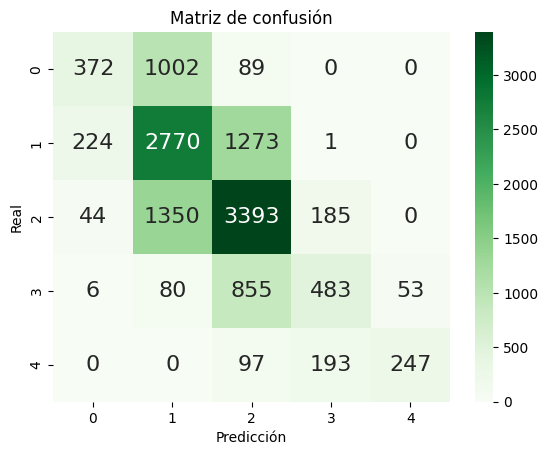

In [51]:
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', annot_kws={"size":16})
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()

El modelo baseline tendía a concentrar gran parte de las predicciones en las clases centrales, especialmente en la clase 1 y 2, dificultando la detección de comportamientos menos frecuentes.

Tras el *feature engineering*:
- aumenta de forma visible la diagonal principal,
- disminuyen las confusiones extremas,
- y aparecen fronteras más claras entre categorías temporales.

En particular, los pedidos rápidos ya no son absorbidos casi completamente por la clase 1, y los pedidos muy largos dejan de confundirse masivamente con la clase 2.

Esto indica que las nuevas variables permiten al modelo capturar mejor patrones operativos específicos y mejorar la separación entre distintos tipos de entrega.

## **7. Conclusiones**

Los resultados obtenidos muestran que el *feature engineering* tiene un impacto significativamente mayor que el simple cambio de paradigma entre regresión y clasificación observado en los modelos baseline.

Mientras que las diferencias iniciales entre ambos enfoques eran relativamente pequeñas, la incorporación de nuevas variables permite mejorar de forma notable la capacidad predictiva del modelo de clasificación.

Especialmente relevante es la mejora en las clases extremas, donde el baseline presentaba mayores dificultades. El incremento del recall en la clase 0 confirma que el nuevo conjunto de *features* permite capturar mejor patrones asociados a entregas rápidas, reduciendo la fuerte tendencia inicial hacia las clases centrales.

En conjunto, los resultados sugieren que una representación más rica del contexto operativo y geográfico resulta clave para modelar correctamente los tiempos de entrega y discriminar entre distintos rangos temporales.